# Install & Import Library

In [37]:
!pip install gensim spacy tensorflow scikit-learn

import numpy as np
import pandas as pd
import spacy
from gensim.models import KeyedVectors
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


# Load spaCy Tokenizer (Indonesia)

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
nlp = spacy.blank("id")  # tokenizer-only, paling cepat

def spacy_tokenize(text):
    return [t.text for t in nlp(text)]


# Load Dataset + Split Train/Val/Test :

In [40]:
file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Step 1: Test split 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Validation 10% dari total → 12.5% dari 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


1445 207 414


# Load FastText Embedding

In [41]:
from gensim.models import KeyedVectors

# Path file .kv hasil convert
save_path = "/content/drive/MyDrive/DistilBERT-7-Mei/fasttext_id.kv"

# Load cepat
w2v = KeyedVectors.load(save_path, mmap='r')

embedding_dim = w2v.vector_size

print("Embedding dim:", embedding_dim)
print("Jumlah kata:", len(w2v))


Embedding dim: 300
Jumlah kata: 2000000


# Build Vocabulary + Convert to Sequence (Menggunakan spaCY)

In [42]:
def build_vocab(texts):
    vocab = {}
    idx = 1  # 0 reserved for PAD

    for txt in texts:
        for tok in spacy_tokenize(txt):
            if tok not in vocab:
                vocab[tok] = idx
                idx += 1
    return vocab

vocab = build_vocab(X_train)
vocab_size = len(vocab) + 1


# Create embedding matrix:

In [43]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in w2v:
        embedding_matrix[idx] = w2v[word]
    else:
        embedding_matrix[idx] = np.random.normal(size=(embedding_dim,))


# Convert text to indexed sequences:

In [44]:
def text_to_sequence(text, vocab, max_len=40):
    tokens = spacy_tokenize(text)
    seq = [vocab.get(tok, 0) for tok in tokens][:max_len]
    seq += [0] * (max_len - len(seq))
    return seq

def convert_dataset(X):
    return np.array([text_to_sequence(t, vocab) for t in X])

X_train_vec = convert_dataset(X_train)
X_val_vec = convert_dataset(X_val)
X_test_vec = convert_dataset(X_test)


# Build Bi-GRU Model (with ReLU + Dropout)

In [45]:
def build_model(h_units, dropout_rate, lr):

    inp = Input(shape=(40,))
    emb = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(inp)

    x = Bidirectional(GRU(h_units, return_sequences=False))(emb)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(dropout_rate)(x)

    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Final Training on Train + Val

In [46]:
# BASELINE Params: {'h_units': 64, 'dropout': 0.3, 'lr': 0.001}
best_h    = 64
best_drop = 0.3
best_lr   = 0.001

final_model = build_model(best_h, best_drop, best_lr)

X_final = np.concatenate([X_train_vec, X_val_vec])
y_final = np.concatenate([y_train, y_val])

final_model.fit(
    X_final, y_final,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5665 - loss: 0.6771
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7704 - loss: 0.5303
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8526 - loss: 0.3567
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8888 - loss: 0.2697
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8888 - loss: 0.2547
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9121 - loss: 0.1966
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9338 - loss: 0.1744
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9452 - loss: 0.1595
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9416 - loss: 0.1570
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9523 - loss: 0.1385


# Evaluation on Test Set

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
              precision    recall  f1-score   support

         0.0     0.8238    0.9430    0.8793       228
         1.0     0.9150    0.7527    0.8260       186

    accuracy                         0.8575       414
   macro avg     0.8694    0.8478    0.8527       414
weighted avg     0.8648    0.8575    0.8554       414



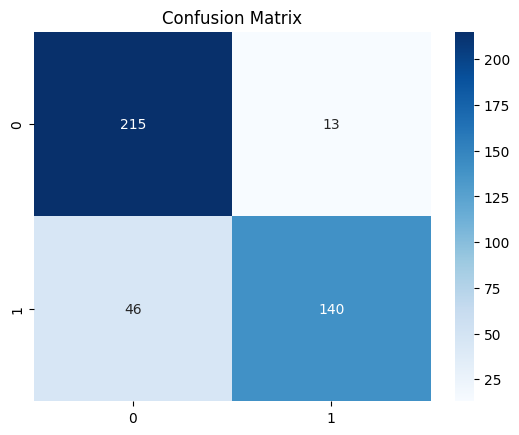

Macro F1: 0.8526521526684402


In [47]:
y_pred = (final_model.predict(X_test_vec) > 0.5).astype("int32")

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))


In [48]:
# === Inference Time Benchmark (selaras dengan BERT) ===
import time
benchmark_size = min(32, len(X_test_vec))
subset = X_test_vec[:benchmark_size]

# Warm-up
for _ in range(3):
    _ = final_model.predict(subset, verbose=0)

# Benchmark
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = final_model.predict(subset, verbose=0)
end = time.time()

avg_time = (end - start) / n_runs
samples_per_second = benchmark_size / avg_time

print("\n🕒 Avg batch inference time:", avg_time)
print("📊 Throughput:", samples_per_second, "samples/sec")


🕒 Avg batch inference time: 0.05790977478027344
📊 Throughput: 552.583741197705 samples/sec
